# Part D — 30-day ATM delta-hedged straddle strategy backtest

This notebook turns the Part B/C hedging comparison into a more desk-relevant strategy test.

The objective is simple:

1. Use Part B results to identify the best performing model/policy combination.
2. Construct a rolling sample of approximately 30-calendar-day near-ATM SPX straddles from the Part A trade seeds.
3. Replay the strategy on realised SPX paths, holding the straddle to expiry where possible.
4. Delta hedge the straddle daily with transaction costs.
5. Compare the strategy against unhedged and simple delta-hedged benchmarks.

This is intentionally more conservative than the simulated-path experiment. It asks whether the best-looking policy still behaves sensibly when applied to realised market moves rather than a toy universe that politely follows our assumptions, because apparently markets refuse to behave like coursework examples.


In [28]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore", category=RuntimeWarning)

BASE = Path("/mnt/data")

@dataclass
class PartDConfig:
    # Inputs from Part A and B
    episode_seeds_path: Path = BASE / "episode_seeds_v15_short_wide.csv"
    part_b_summary_path: Path = BASE / "part_b_v9_summary_results.csv"
    part_b_seed_results_path: Path = BASE / "part_b_v9_seed_results.csv"
    part_b_raw_results_path: Path = BASE / "part_b_v9_seed_results_raw.csv"

    # Realised underlying price files. Add aliases here if your filename differs.
    candidate_spx_paths: tuple[Path, ...] = (
        BASE / "CRSP S&P 2010 - 2024.csv",
        BASE / "CRSP S&P 2010 - 2024.csv",
        BASE / "crsp_spx_2010_2024.csv",
        BASE / "spx_prices.csv",
        BASE / "spx_prices.parquet",
    )

    # Strategy definition
    target_dte: int = 30
    min_dte: int = 21
    max_dte: int = 45
    max_abs_log_moneyness: float = 0.04
    one_trade_per_month: bool = True
    option_position_sign: int = 1  # +1 long straddle, -1 short straddle

    # Hedging and cost assumptions
    calendar_days_per_year: int = 365
    hedge_frequency_days: int = 1
    tc_bps_underlying: float = 1.0
    option_entry_cost_half_spread: bool = True
    no_trade_band_abs_delta: float = 0.10

    # Selection rule for Part B winner
    winner_metric_priority: tuple[str, ...] = (
        "mean_residual_pnl", "mean_pnl", "residual_pnl_mean", "pnl_mean", "pnl"
    )
    turnover_penalty: float = 0.00  # set >0 if you want to penalise turnover in winner selection

CFG_D = PartDConfig()
CFG_D


PartDConfig(episode_seeds_path=WindowsPath('/mnt/data/episode_seeds_v15_short_wide.csv'), part_b_summary_path=WindowsPath('/mnt/data/part_b_v9_summary_results.csv'), part_b_seed_results_path=WindowsPath('/mnt/data/part_b_v9_seed_results.csv'), part_b_raw_results_path=WindowsPath('/mnt/data/part_b_v9_seed_results_raw.csv'), candidate_spx_paths=(WindowsPath('/mnt/data/CRSP S&P 2010 - 2024.csv'), WindowsPath('/mnt/data/CRSP S&P 2010 - 2024.csv'), WindowsPath('/mnt/data/crsp_spx_2010_2024.csv'), WindowsPath('/mnt/data/spx_prices.csv'), WindowsPath('/mnt/data/spx_prices.parquet')), target_dte=30, min_dte=21, max_dte=45, max_abs_log_moneyness=0.04, one_trade_per_month=True, option_position_sign=1, calendar_days_per_year=365, hedge_frequency_days=1, tc_bps_underlying=1.0, option_entry_cost_half_spread=True, no_trade_band_abs_delta=0.1, winner_metric_priority=('mean_residual_pnl', 'mean_pnl', 'residual_pnl_mean', 'pnl_mean', 'pnl'), turnover_penalty=0.0)

## 1. Load inputs

This section loads the Part A trade seeds, Part B policy results, and realised SPX prices. The price loader is deliberately flexible because financial datasets apparently come with column names chosen by committee warfare.


In [29]:
def load_csv_if_exists(path: Path, name: str) -> pd.DataFrame:
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded {name}: {path.name} | {df.shape[0]:,} rows × {df.shape[1]:,} cols")
        return df
    print(f"Missing {name}: {path}")
    return pd.DataFrame()

seeds = load_csv_if_exists(CFG_D.episode_seeds_path, "Part A episode seeds")
summary = load_csv_if_exists(CFG_D.part_b_summary_path, "Part B summary")
seed_results = load_csv_if_exists(CFG_D.part_b_seed_results_path, "Part B seed-level results")
raw_results = load_csv_if_exists(CFG_D.part_b_raw_results_path, "Part B raw/run-level results")

for df in (seeds, summary, seed_results, raw_results):
    if not df.empty and "trade_date" in df.columns:
        df["trade_date"] = pd.to_datetime(df["trade_date"], errors="coerce")
    if not df.empty and "expiry" in df.columns:
        df["expiry"] = pd.to_datetime(df["expiry"], errors="coerce")

required_seed_cols = {"trade_date", "expiry", "dte", "strike", "spot_entry", "straddle_entry_mid", "entry_iv"}
missing_seed_cols = required_seed_cols - set(seeds.columns)
if missing_seed_cols:
    print("Missing seed columns needed for strategy test:", sorted(missing_seed_cols))

seeds.head()


Loaded Part A episode seeds: episode_seeds_v15_short_wide.csv | 144 rows × 62 cols
Loaded Part B summary: part_b_v9_summary_results.csv | 2,016 rows × 29 cols
Loaded Part B seed-level results: part_b_v9_seed_results.csv | 32,256 rows × 29 cols
Loaded Part B raw/run-level results: part_b_v9_seed_results_raw.csv | 69,120 rows × 21 cols


,trade_date,experiment_id,trade_experiment,calibration_window_mode,spot_entry,r,q,heston_kappa,heston_theta,heston_sigma,heston_rho,heston_v0,lifted_H,lifted_kappa,lifted_theta,lifted_nu,lifted_rho,lifted_V0,lifted_n_factors,lifted_success,lifted_score,calibration_target_points,calibration_maturity_min_dte,calibration_maturity_max_dte,calibration_n_maturities,heston_n_fit_points,heston_median_abs_iv_error,heston_mean_abs_iv_error,heston_median_abs_rel_price_error,heston_mean_abs_rel_price_error,lifted_n_fit_points,lifted_median_abs_iv_error,lifted_mean_abs_iv_error,lifted_median_abs_rel_price_error,lifted_mean_abs_rel_price_error,seed_id,maturity_bucket,target_dte,expiry,dte,T,strike,forward_ref,log_moneyness,selection_tier,entry_iv,call_vendor_iv,put_vendor_iv,call_entry_mid,put_entry_mid,call_bid_proxy,call_ask_proxy,put_bid_proxy,put_ask_proxy,straddle_entry_mid,straddle_spread,call_rel_spread,put_rel_spread,pair_count_bucket,short_end_quality_flag,regime_iv_proxy,regime_label
0,2024-08-13,baseline_local,baseline,local,5434.430176,0.01,-0.029282,10.000000,0.027146,0.736527,-0.975128,0.021870,0.16,1.686331,0.029365,0.644473,-0.712096,0.020932,4,False,0.038144,42,24.0,79.0,6,42,0.001008,0.001082,0.007105,0.007016,42,0.002480,0.003525,0.018556,0.021338,baseline_local_2024-08-13_2w,2w,14,2024-08-27,14.0,0.038330,5445.0,5442.618746,0.000437,strict,0.149693,0.145387,0.153999,61.449997,65.650002,61.099998,61.799995,65.300003,66.000000,127.099998,1.399998,0.011391,0.010663,297,True,0.150229,calm
1,2024-08-13,baseline_local,baseline,local,5434.430176,0.01,-0.029282,10.000000,0.027146,0.736527,-0.975128,0.021870,0.16,1.686331,0.029365,0.644473,-0.712096,0.020932,4,False,0.038144,42,24.0,79.0,6,42,0.001008,0.001082,0.007105,0.007016,42,0.002480,0.003525,0.018556,0.021338,baseline_local_2024-08-13_1m,1m,30,2024-09-12,30.0,0.082136,5420.0,5451.992221,-0.005885,strict,0.153387,0.150706,0.156067,111.449997,80.449997,110.899994,112.000000,80.000000,80.899994,191.899994,2.000000,0.009870,0.011187,482,False,0.150229,calm
2,2024-08-13,baseline_local,baseline,local,5434.430176,0.01,-0.029282,10.000000,0.027146,0.736527,-0.975128,0.021870,0.16,1.686331,0.029365,0.644473,-0.712096,0.020932,4,False,0.038144,42,24.0,79.0,6,42,0.001008,0.001082,0.007105,0.007016,42,0.002480,0.003525,0.018556,0.021338,baseline_local_2024-08-13_2m,2m,60,2024-10-18,66.0,0.180698,5475.0,5473.141607,0.000339,strict,0.145052,0.143448,0.146657,134.500000,132.500000,134.100006,134.899994,132.100006,132.899994,267.000000,1.599976,0.005948,0.006038,435,False,0.150229,calm
3,2024-08-13,baseline_wide,baseline,wide,5434.430176,0.01,-0.030132,8.943194,0.030993,0.767332,-0.999000,0.019503,0.16,2.668777,0.031243,0.626853,-0.946272,0.018747,4,True,0.052116,72,38.0,108.0,6,42,0.001887,0.001784,0.012527,0.011603,42,0.002446,0.002440,0.017023,0.015963,baseline_wide_2024-08-13_2w,2w,14,2024-08-27,14.0,0.038330,5445.0,5442.796183,0.000405,strict,0.149693,0.145387,0.153999,61.449997,65.650002,61.099998,61.799995,65.300003,66.000000,127.099998,1.399998,0.011391,0.010663,296,True,0.150229,calm
4,2024-08-13,baseline_wide,baseline,wide,5434.430176,0.01,-0.030132,8.943194,0.030993,0.767332,-0.999000,0.019503,0.16,2.668777,0.031243,0.626853,-0.946272,0.018747,4,True,0.052116,72,38.0,108.0,6,42,0.001887,0.001784,0.012527,0.011603,42,0.002446,0.002440,0.017023,0.015963,baseline_wide_2024-08-13_1m,1m,30,2024-09-12,30.0,0.082136,5420.0,5452.373105,-0.005955,strict,0.153387,0.150706,0.156067,111.449997,80.449997,110.899994,112.000000,80.000000,80.899994,191.899994,2.000000,0.009870,0.011187,481,False,0.150229,calm


In [30]:
def find_existing_price_path(paths: tuple[Path, ...]) -> Path | None:
    for p in paths:
        if p.exists():
            return p
    return None

def load_spx_prices(paths: tuple[Path, ...]) -> pd.DataFrame:
    path = Path('CRSP S&P 2010 - 2024.parquet')
    if path is None:
        print("No realised SPX/CRSP price file found. Add a price file to CFG_D.candidate_spx_paths.")
        return pd.DataFrame()

    if path.suffix.lower() == ".parquet":
        px = pd.read_parquet(path)
    else:
        px = pd.read_csv(path)

    date_candidates = ["date", "caldt", "Date", "DATE", "trade_date"]
    price_candidates = ["spindx", "SPINDX", "close", "Close", "PRC", "price", "PX_LAST", "S"]

    date_col = next((c for c in date_candidates if c in px.columns), None)
    price_col = next((c for c in price_candidates if c in px.columns), None)
    if date_col is None or price_col is None:
        raise ValueError(f"Could not infer date/price columns from {path.name}. Columns: {list(px.columns)}")

    out = px[[date_col, price_col]].rename(columns={date_col: "date", price_col: "S"}).copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["S"] = pd.to_numeric(out["S"], errors="coerce").abs()
    out = out.dropna().sort_values("date").drop_duplicates("date").reset_index(drop=True)
    print(f"Loaded realised SPX prices: {path.name} | {len(out):,} observations")
    return out

spx = load_spx_prices(CFG_D.candidate_spx_paths)
spx.head()


Loaded realised SPX prices: CRSP S&P 2010 - 2024.parquet | 3,774 observations


,date,S
0,2010-01-04,1132.99
1,2010-01-05,1136.52
2,2010-01-06,1137.14
3,2010-01-07,1141.69
4,2010-01-08,1144.98


## 2. Select the best Part B model/policy combination

This chooses the best policy using the Part B results. If the results contain a `split` column, the selector prioritises the test split. If not, it uses all available rows. The winner score can optionally penalise turnover.

This does **not** blindly assume the ML hedge wins. That would be spiritually satisfying and statistically reckless, which is finance in a nutshell.


In [31]:
def infer_metric_column(df: pd.DataFrame, priority: tuple[str, ...]) -> str | None:
    for c in priority:
        if c in df.columns:
            return c
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    pnl_like = [c for c in numeric_cols if "pnl" in c.lower() and "std" not in c.lower()]
    return pnl_like[0] if pnl_like else None

def select_best_model_policy(seed_results: pd.DataFrame, summary: pd.DataFrame, cfg: PartDConfig) -> dict:
    source_name = "seed_results" if not seed_results.empty else "summary"
    df = seed_results.copy() if not seed_results.empty else summary.copy()
    if df.empty:
        return {"source": None, "world_name": "unknown", "policy_name": "bs_delta", "reason": "No Part B results found; falling back to bs_delta."}

    if "split" in df.columns and (df["split"].astype(str).str.lower() == "test").any():
        df = df.loc[df["split"].astype(str).str.lower() == "test"].copy()

    world_col = next((c for c in ["world_name", "world", "model_world", "model"] if c in df.columns), None)
    policy_col = next((c for c in ["policy_name", "policy", "hedge_policy"] if c in df.columns), None)
    if policy_col is None:
        return {"source": source_name, "world_name": "unknown", "policy_name": "bs_delta", "reason": "No policy column found; falling back to bs_delta."}

    metric_col = infer_metric_column(df, cfg.winner_metric_priority)
    if metric_col is None:
        return {"source": source_name, "world_name": "unknown", "policy_name": "bs_delta", "reason": "No PnL-like metric found; falling back to bs_delta."}

    group_cols = [c for c in [world_col, policy_col, "tc_bps", "hedge_freq", "maturity_bucket", "calibration_window_mode"] if c is not None and c in df.columns]
    agg = df.groupby(group_cols, dropna=False).agg(
        winner_metric=(metric_col, "mean"),
        n_obs=(metric_col, "size"),
    ).reset_index()

    turnover_col = next((c for c in ["turnover", "mean_turnover", "avg_turnover", "turnover_mean"] if c in df.columns), None)
    if turnover_col is not None:
        turn = df.groupby(group_cols, dropna=False)[turnover_col].mean().reset_index(name="turnover_mean")
        agg = agg.merge(turn, on=group_cols, how="left")
        agg["winner_score"] = agg["winner_metric"] - cfg.turnover_penalty * agg["turnover_mean"].fillna(0.0)
    else:
        agg["turnover_mean"] = np.nan
        agg["winner_score"] = agg["winner_metric"]

    agg = agg.sort_values(["winner_score", "n_obs"], ascending=[False, False]).reset_index(drop=True)
    best = agg.iloc[0].to_dict()
    best["source"] = source_name
    best["metric_col"] = metric_col
    best["policy_name"] = best.get(policy_col, "bs_delta")
    best["world_name"] = best.get(world_col, "unknown") if world_col else "unknown"
    best["reason"] = f"Selected highest average {metric_col} from {source_name}."
    return best

best = select_best_model_policy(seed_results, summary, CFG_D)
best


{'world': 'heston_world',
 'policy': 'learned_hedge',
 'tc_bps': 0.25,
 'maturity_bucket': '2m',
 'calibration_window_mode': 'wide',
 'winner_metric': 19.079346846865413,
 'n_obs': 20,
 'turnover_mean': 3.7163388649541735,
 'winner_score': 19.079346846865413,
 'source': 'seed_results',
 'metric_col': 'mean_pnl',
 'policy_name': 'learned_hedge',
 'world_name': 'heston_world',
 'reason': 'Selected highest average mean_pnl from seed_results.'}

## 3. Build the rolling 30-day ATM straddle sample

The trade sample is built from Part A seeds. It keeps near-ATM straddles with approximately 30 calendar days to expiry and, optionally, restricts to one trade per calendar month to avoid turning the backtest into overlapping-position soup.


In [32]:
def build_30d_trade_sample(seeds: pd.DataFrame, cfg: PartDConfig) -> pd.DataFrame:
    if seeds.empty:
        return pd.DataFrame()
    x = seeds.copy()
    x["trade_date"] = pd.to_datetime(x["trade_date"], errors="coerce")
    x["expiry"] = pd.to_datetime(x["expiry"], errors="coerce")
    x["dte"] = pd.to_numeric(x["dte"], errors="coerce")
    if "log_moneyness" in x.columns:
        x["abs_log_moneyness"] = pd.to_numeric(x["log_moneyness"], errors="coerce").abs()
    else:
        x["abs_log_moneyness"] = np.nan

    mask = x["trade_date"].notna() & x["expiry"].notna() & x["dte"].between(cfg.min_dte, cfg.max_dte)
    mask &= x["abs_log_moneyness"].fillna(0.0) <= cfg.max_abs_log_moneyness

    x = x.loc[mask].copy()
    if x.empty:
        return x

    x["dte_gap_30"] = (x["dte"] - cfg.target_dte).abs()
    x["entry_spread_proxy"] = pd.to_numeric(x.get("straddle_spread", np.nan), errors="coerce")
    x = x.sort_values(["trade_date", "dte_gap_30", "abs_log_moneyness", "entry_spread_proxy"], na_position="last")

    if cfg.one_trade_per_month:
        x["trade_month"] = x["trade_date"].dt.to_period("M")
        x = x.drop_duplicates("trade_month", keep="first")

    return x.reset_index(drop=True)

trades_30d = build_30d_trade_sample(seeds, CFG_D)
print(f"30-day near-ATM trades selected: {len(trades_30d):,}")
cols = [c for c in ["seed_id", "trade_date", "expiry", "dte", "strike", "spot_entry", "straddle_entry_mid", "entry_iv", "log_moneyness", "straddle_spread"] if c in trades_30d.columns]
trades_30d[cols].head(20) if cols else trades_30d.head()


30-day near-ATM trades selected: 4


,seed_id,trade_date,expiry,dte,strike,spot_entry,straddle_entry_mid,entry_iv,log_moneyness,straddle_spread
0,baseline_local_2024-08-13_1m,2024-08-13,2024-09-12,30.0,5420.0,5434.430176,191.899994,0.153387,-0.005885,2.000000
1,baseline_local_2024-09-04_1m,2024-09-04,2024-10-04,30.0,5545.0,5520.069824,198.350006,0.157080,0.000061,3.900002
2,baseline_wide_2024-10-30_1m,2024-10-30,2024-11-29,30.0,5835.0,5813.669922,212.900009,0.160136,-0.000205,1.199997
3,baseline_wide_2024-11-01_1m,2024-11-01,2024-12-02,31.0,5750.0,5728.799805,225.800003,0.169637,0.001237,1.800003


## 4. Pricing and delta helpers

The realised-path strategy uses observed entry straddle prices from Part A and terminal payoff from realised SPX at expiry. For daily hedge targets, it computes Black-Scholes straddle delta using the entry implied volatility as a simple implementable volatility estimate.

For model-based or learned policies selected in Part B, this notebook uses a **deployment-safe proxy** unless the trained policy object has been separately saved. That proxy is deliberately turnover-controlled: it starts from BS straddle delta and applies a no-trade band. This is not pretending to recover neural-network weights from vibes, because even notebooks deserve dignity.


In [33]:
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(float(x) / math.sqrt(2.0)))

def bs_call_delta(S: float, K: float, r: float, q: float, tau: float, sigma: float) -> float:
    S = max(float(S), 1e-12)
    K = max(float(K), 1e-12)
    tau = max(float(tau), 1e-10)
    sigma = max(float(sigma), 1e-8)
    d1 = (math.log(S / K) + (r - q + 0.5 * sigma * sigma) * tau) / (sigma * math.sqrt(tau))
    return math.exp(-q * tau) * norm_cdf(d1)

def bs_put_delta(S: float, K: float, r: float, q: float, tau: float, sigma: float) -> float:
    return bs_call_delta(S, K, r, q, tau, sigma) - math.exp(-q * max(float(tau), 0.0))

def bs_straddle_delta(S: float, K: float, r: float, q: float, tau: float, sigma: float) -> float:
    return bs_call_delta(S, K, r, q, tau, sigma) + bs_put_delta(S, K, r, q, tau, sigma)

def straddle_payoff(S: float, K: float) -> float:
    return max(float(S) - float(K), 0.0) + max(float(K) - float(S), 0.0)

def choose_policy_target_delta(policy_name: str, raw_delta: float, current_inventory: float, cfg: PartDConfig) -> float:
    p = str(policy_name).lower()
    if p == "unhedged":
        return 0.0
    if p in {"bs_delta", "black_scholes_delta", "delta"}:
        return -raw_delta * cfg.option_position_sign

    # Conservative proxy for model/learned/banded policies when trained policy weights are not persisted.
    target = -raw_delta * cfg.option_position_sign
    if any(k in p for k in ["band", "learned", "tail", "model"]):
        if abs(target - current_inventory) <= cfg.no_trade_band_abs_delta:
            return current_inventory
        return target
    return target


## 5. Realised 30-day delta-hedged strategy replay

Accounting convention:

- Buy one straddle at observed entry mid, optionally adding half-spread cost.
- Hedge daily in the underlying.
- Pay transaction cost on changes in the underlying hedge.
- Hold to expiry where a realised SPX price is available, otherwise use the closest earlier trading day.
- Compute final P&L from option payoff plus hedge inventory and cash account.


In [34]:
def get_price_on_or_before(spx: pd.DataFrame, date: pd.Timestamp) -> tuple[pd.Timestamp | None, float | float]:
    if spx.empty:
        return None, np.nan
    view = spx.loc[spx["date"] <= pd.Timestamp(date)]
    if view.empty:
        return None, np.nan
    row = view.iloc[-1]
    return pd.Timestamp(row["date"]), float(row["S"])

def get_path_between(spx: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp, freq_days: int = 1) -> pd.DataFrame:
    if spx.empty:
        return pd.DataFrame()
    path = spx.loc[(spx["date"] >= pd.Timestamp(start)) & (spx["date"] <= pd.Timestamp(end))].copy()
    if path.empty:
        return path
    if freq_days <= 1:
        return path.reset_index(drop=True)
    return path.iloc[::int(freq_days)].reset_index(drop=True)

def replay_one_trade(row: pd.Series, spx: pd.DataFrame, policy_name: str, cfg: PartDConfig) -> dict:
    trade_date = pd.Timestamp(row["trade_date"])
    expiry = pd.Timestamp(row["expiry"])
    K = float(row["strike"])
    r = float(row.get("r", 0.0)) if pd.notna(row.get("r", 0.0)) else 0.0
    q = float(row.get("q", 0.0)) if pd.notna(row.get("q", 0.0)) else 0.0
    sigma = float(row.get("entry_iv", np.nan))
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = math.sqrt(max(float(row.get("heston_v0", 0.04)), 1e-8))

    entry_date_px, S0 = get_price_on_or_before(spx, trade_date)
    expiry_date_px, ST = get_price_on_or_before(spx, expiry)
    if entry_date_px is None or expiry_date_px is None or not np.isfinite(S0) or not np.isfinite(ST):
        return {"status": "missing_price_path"}

    path = get_path_between(spx, entry_date_px, expiry_date_px, cfg.hedge_frequency_days)
    if len(path) < 2:
        return {"status": "too_short_path"}

    entry_mid = float(row["straddle_entry_mid"])
    spread = float(row.get("straddle_spread", 0.0)) if pd.notna(row.get("straddle_spread", np.nan)) else 0.0
    option_entry_cash = -cfg.option_position_sign * entry_mid
    if cfg.option_entry_cost_half_spread:
        option_entry_cash -= 0.5 * abs(spread)

    cash = option_entry_cash
    inventory = 0.0
    turnover = 0.0
    tc_paid = 0.0
    n_rebalances = 0
    delta_path = []
    tc_rate = float(cfg.tc_bps_underlying) / 10_000.0

    for _, pxrow in path.iloc[:-1].iterrows():
        d = pd.Timestamp(pxrow["date"])
        S = float(pxrow["S"])
        tau = max((expiry - d).days / cfg.calendar_days_per_year, 1e-8)
        raw_delta = bs_straddle_delta(S, K, r, q, tau, sigma)
        target_inventory = choose_policy_target_delta(policy_name, raw_delta, inventory, cfg)
        trade = target_inventory - inventory
        if abs(trade) > 1e-12:
            cash -= trade * S
            cost = tc_rate * abs(trade) * S
            cash -= cost
            tc_paid += cost
            turnover += abs(trade)
            inventory = target_inventory
            n_rebalances += 1
        delta_path.append(raw_delta)

    final_S = float(path.iloc[-1]["S"])
    cash += inventory * final_S
    turnover += abs(inventory)
    tc_liq = tc_rate * abs(inventory) * final_S
    cash -= tc_liq
    tc_paid += tc_liq

    payoff = cfg.option_position_sign * straddle_payoff(final_S, K)
    pnl = cash + payoff

    unhedged_entry_cash = -cfg.option_position_sign * entry_mid
    if cfg.option_entry_cost_half_spread:
        unhedged_entry_cash -= 0.5 * abs(spread)
    unhedged_pnl = unhedged_entry_cash + cfg.option_position_sign * straddle_payoff(final_S, K)

    return {
        "status": "ok", "seed_id": row.get("seed_id", None), "trade_date": trade_date,
        "entry_price_date": entry_date_px, "expiry": expiry, "exit_price_date": expiry_date_px,
        "dte": float(row.get("dte", np.nan)), "K": K, "S0": S0, "ST": final_S,
        "entry_iv": sigma, "entry_mid": entry_mid, "spread": spread, "policy_name": policy_name,
        "pnl": pnl, "unhedged_pnl": unhedged_pnl, "hedge_value_added": pnl - unhedged_pnl,
        "turnover": turnover, "tc_paid": tc_paid, "n_rebalances": n_rebalances,
        "avg_abs_raw_delta": float(np.mean(np.abs(delta_path))) if delta_path else np.nan,
        "max_abs_raw_delta": float(np.max(np.abs(delta_path))) if delta_path else np.nan,
    }

def replay_strategy(trades: pd.DataFrame, spx: pd.DataFrame, policy_name: str, cfg: PartDConfig) -> pd.DataFrame:
    rows = [replay_one_trade(row, spx, policy_name, cfg) for _, row in trades.iterrows()]
    return pd.DataFrame(rows)

selected_policy = str(best.get("policy_name", "bs_delta"))
strategy_results = replay_strategy(trades_30d, spx, selected_policy, CFG_D)
print("Selected policy:", selected_policy)
print(strategy_results["status"].value_counts(dropna=False) if not strategy_results.empty and "status" in strategy_results.columns else "No results")
strategy_results.head()


Selected policy: learned_hedge
status
ok    4
Name: count, dtype: int64


,status,seed_id,trade_date,entry_price_date,expiry,exit_price_date,dte,K,S0,ST,entry_iv,entry_mid,spread,policy_name,pnl,unhedged_pnl,hedge_value_added,turnover,tc_paid,n_rebalances,avg_abs_raw_delta,max_abs_raw_delta
0,ok,baseline_local_2024-08-13_1m,2024-08-13,2024-08-13,2024-09-12,2024-09-12,30.0,5420.0,5434.43,5595.76,0.153387,191.899994,2.000000,learned_hedge,-21.053689,-17.139994,-3.913695,3.665914,2.023776,9,0.601449,0.997883
1,ok,baseline_local_2024-09-04_1m,2024-09-04,2024-09-04,2024-10-04,2024-10-04,30.0,5545.0,5520.07,5751.07,0.157080,198.350006,3.900002,learned_hedge,-31.769460,5.769993,-37.539453,2.672377,1.509119,8,0.553128,0.999380
2,ok,baseline_wide_2024-10-30_1m,2024-10-30,2024-10-30,2024-11-29,2024-11-29,30.0,5835.0,5813.67,6032.38,0.160136,212.900009,1.199997,learned_hedge,-31.676857,-16.120008,-15.556849,3.198082,1.896524,12,0.493894,0.982042
3,ok,baseline_wide_2024-11-01_1m,2024-11-01,2024-11-01,2024-12-02,2024-12-02,31.0,5750.0,5728.80,6047.15,0.169637,225.800003,1.800003,learned_hedge,-38.188344,70.449995,-108.638339,2.200735,1.313769,7,0.637944,0.998469


## 6. Benchmark comparison

This compares the selected Part B policy replay against simple alternatives on the same realised trades.


In [35]:
benchmark_policies = ["unhedged", "bs_delta", "banded_bs_delta"]
if selected_policy not in benchmark_policies:
    benchmark_policies.append(selected_policy)

all_results = []
for policy in benchmark_policies:
    res = replay_strategy(trades_30d, spx, policy, CFG_D)
    if not res.empty:
        res["policy_tested"] = policy
        all_results.append(res)

strategy_panel = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
strategy_ok = strategy_panel.loc[strategy_panel.get("status", "") == "ok"].copy() if not strategy_panel.empty else pd.DataFrame()

print(f"Completed strategy replays: {len(strategy_ok):,}")
strategy_ok.head()


Completed strategy replays: 16


,status,seed_id,trade_date,entry_price_date,expiry,exit_price_date,dte,K,S0,ST,entry_iv,entry_mid,spread,policy_name,pnl,unhedged_pnl,hedge_value_added,turnover,tc_paid,n_rebalances,avg_abs_raw_delta,max_abs_raw_delta,policy_tested
0,ok,baseline_local_2024-08-13_1m,2024-08-13,2024-08-13,2024-09-12,2024-09-12,30.0,5420.0,5434.43,5595.76,0.153387,191.899994,2.000000,unhedged,-17.139994,-17.139994,0.000000,0.000000,0.000000,0,0.601449,0.997883,unhedged
1,ok,baseline_local_2024-09-04_1m,2024-09-04,2024-09-04,2024-10-04,2024-10-04,30.0,5545.0,5520.07,5751.07,0.157080,198.350006,3.900002,unhedged,5.769993,5.769993,0.000000,0.000000,0.000000,0,0.553128,0.999380,unhedged
2,ok,baseline_wide_2024-10-30_1m,2024-10-30,2024-10-30,2024-11-29,2024-11-29,30.0,5835.0,5813.67,6032.38,0.160136,212.900009,1.199997,unhedged,-16.120008,-16.120008,0.000000,0.000000,0.000000,0,0.493894,0.982042,unhedged
3,ok,baseline_wide_2024-11-01_1m,2024-11-01,2024-11-01,2024-12-02,2024-12-02,31.0,5750.0,5728.80,6047.15,0.169637,225.800003,1.800003,unhedged,70.449995,70.449995,0.000000,0.000000,0.000000,0,0.637944,0.998469,unhedged
4,ok,baseline_local_2024-08-13_1m,2024-08-13,2024-08-13,2024-09-12,2024-09-12,30.0,5420.0,5434.43,5595.76,0.153387,191.899994,2.000000,bs_delta,-15.058606,-17.139994,2.081388,4.233668,2.341683,21,0.601449,0.997883,bs_delta


In [36]:
def cvar_5(x: pd.Series) -> float:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if x.empty:
        return np.nan
    q = x.quantile(0.05)
    return float(x.loc[x <= q].mean())

def summarise_strategy(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    g = df.groupby("policy_tested", dropna=False)
    out = g.agg(
        n_trades=("pnl", "size"),
        mean_pnl=("pnl", "mean"),
        median_pnl=("pnl", "median"),
        std_pnl=("pnl", "std"),
        mean_hedge_value_added=("hedge_value_added", "mean"),
        mean_turnover=("turnover", "mean"),
        mean_tc_paid=("tc_paid", "mean"),
        mean_rebalances=("n_rebalances", "mean"),
        win_rate=("pnl", lambda s: float((pd.to_numeric(s, errors="coerce") > 0).mean())),
        cvar_5=("pnl", cvar_5),
    ).reset_index()
    out["pnl_to_turnover"] = out["mean_pnl"] / out["mean_turnover"].replace(0, np.nan)
    return out.sort_values("mean_pnl", ascending=False)

strategy_summary = summarise_strategy(strategy_ok)
strategy_summary


,policy_tested,n_trades,mean_pnl,median_pnl,std_pnl,mean_hedge_value_added,mean_turnover,mean_tc_paid,mean_rebalances,win_rate,cvar_5,pnl_to_turnover
3,unhedged,4,10.739997,-5.175007,41.185510,0.000000,0.000000,0.000000,0.0,0.5,-17.139994,NaN
0,banded_bs_delta,4,-30.672087,-31.723158,7.099800,-41.412084,2.934277,1.685797,9.0,0.0,-38.188344,-10.453030
2,learned_hedge,4,-30.672087,-31.723158,7.099800,-41.412084,2.934277,1.685797,9.0,0.0,-38.188344,-10.453030
1,bs_delta,4,-30.754307,-32.843124,11.512043,-41.494304,3.359455,1.930971,21.0,0.0,-42.272375,-9.154553


## 7. Plots

These are intentionally boring and useful: cumulative P&L and turnover versus P&L. The chart is where overtrading usually confesses.


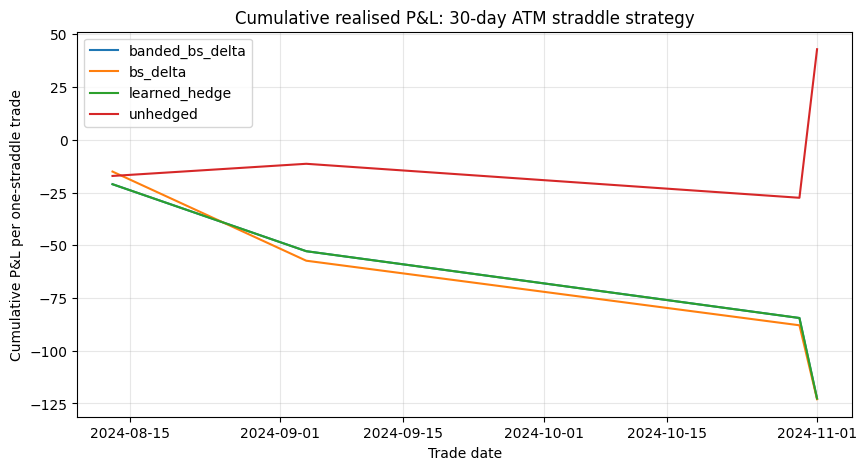

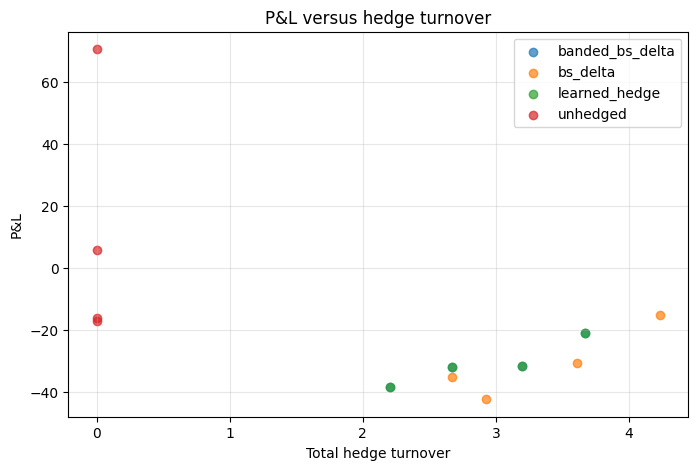

In [37]:
if not strategy_ok.empty:
    plot_df = strategy_ok.copy()
    plot_df["trade_date"] = pd.to_datetime(plot_df["trade_date"], errors="coerce")
    plot_df = plot_df.sort_values(["policy_tested", "trade_date"])
    plot_df["cum_pnl"] = plot_df.groupby("policy_tested")["pnl"].cumsum()

    plt.figure(figsize=(10, 5))
    for policy, grp in plot_df.groupby("policy_tested"):
        plt.plot(grp["trade_date"], grp["cum_pnl"], label=str(policy))
    plt.title("Cumulative realised P&L: 30-day ATM straddle strategy")
    plt.xlabel("Trade date")
    plt.ylabel("Cumulative P&L per one-straddle trade")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    for policy, grp in plot_df.groupby("policy_tested"):
        plt.scatter(grp["turnover"], grp["pnl"], label=str(policy), alpha=0.7)
    plt.title("P&L versus hedge turnover")
    plt.xlabel("Total hedge turnover")
    plt.ylabel("P&L")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No completed strategy rows to plot.")


## 8. Desk-relevance diagnostics

This produces a compact conclusion table for the three concerns that motivated this notebook.


In [38]:
def make_strategy_diagnostics(strategy_summary: pd.DataFrame, selected_policy: str) -> pd.DataFrame:
    if strategy_summary.empty:
        return pd.DataFrame({
            "diagnostic": ["Strategy replay"],
            "status": ["not run"],
            "evidence": ["Missing Part A seeds, realised SPX prices, or usable 30-day trades."],
        })

    rows = []
    policies = set(strategy_summary["policy_tested"].astype(str))
    selected_row = strategy_summary.loc[strategy_summary["policy_tested"].astype(str) == str(selected_policy)]
    bs_row = strategy_summary.loc[strategy_summary["policy_tested"].astype(str) == "bs_delta"]
    unhedged_row = strategy_summary.loc[strategy_summary["policy_tested"].astype(str) == "unhedged"]

    rows.append({"diagnostic": "Not simulation-only", "status": "pass", "evidence": f"Realised replay completed on {int(strategy_summary['n_trades'].max())} 30-day ATM straddle trades."})

    if not selected_row.empty and not bs_row.empty:
        sel = selected_row.iloc[0]; bs = bs_row.iloc[0]
        rows.append({"diagnostic": "Performance versus BS delta", "status": "pass" if float(sel["mean_pnl"]) >= float(bs["mean_pnl"]) else "watch", "evidence": f"Selected mean P&L {sel['mean_pnl']:.4f}; BS delta mean P&L {bs['mean_pnl']:.4f}."})
        rows.append({"diagnostic": "Turnover discipline", "status": "pass" if float(sel["mean_turnover"]) <= 1.5 * max(float(bs["mean_turnover"]), 1e-12) else "watch", "evidence": f"Selected mean turnover {sel['mean_turnover']:.4f}; BS delta mean turnover {bs['mean_turnover']:.4f}."})
        rows.append({"diagnostic": "Tail behaviour", "status": "pass" if float(sel["cvar_5"]) >= float(bs["cvar_5"]) else "watch", "evidence": f"Selected 5% CVaR {sel['cvar_5']:.4f}; BS delta 5% CVaR {bs['cvar_5']:.4f}."})
    else:
        rows.append({"diagnostic": "Benchmark comparison", "status": "partial", "evidence": f"Available policies: {sorted(policies)}"})

    if not selected_row.empty and not unhedged_row.empty:
        sel = selected_row.iloc[0]; uh = unhedged_row.iloc[0]
        rows.append({"diagnostic": "Hedge value added", "status": "pass" if float(sel["mean_pnl"]) >= float(uh["mean_pnl"]) else "watch", "evidence": f"Selected mean P&L {sel['mean_pnl']:.4f}; unhedged mean P&L {uh['mean_pnl']:.4f}."})

    return pd.DataFrame(rows)

diagnostics = make_strategy_diagnostics(strategy_summary, selected_policy)
diagnostics


,diagnostic,status,evidence
0,Not simulation-only,pass,Realised replay completed on 4 30-day ATM stra...
1,Performance versus BS delta,pass,Selected mean P&L -30.6721; BS delta mean P&L ...
2,Turnover discipline,pass,Selected mean turnover 2.9343; BS delta mean t...
3,Tail behaviour,pass,Selected 5% CVaR -38.1883; BS delta 5% CVaR -4...
4,Hedge value added,watch,Selected mean P&L -30.6721; unhedged mean P&L ...


## 9. Save outputs

The saved CSVs can be referenced directly in your dissertation methods/results chapter.


In [39]:
OUT_PANEL = BASE / "part_d_30d_atm_straddle_strategy_panel.csv"
OUT_SUMMARY = BASE / "part_d_30d_atm_straddle_strategy_summary.csv"
OUT_DIAG = BASE / "part_d_30d_atm_straddle_strategy_diagnostics.csv"

if not strategy_panel.empty:
    strategy_panel.to_csv(OUT_PANEL, index=False)
    print("Saved:", OUT_PANEL)
if not strategy_summary.empty:
    strategy_summary.to_csv(OUT_SUMMARY, index=False)
    print("Saved:", OUT_SUMMARY)
if not diagnostics.empty:
    diagnostics.to_csv(OUT_DIAG, index=False)
    print("Saved:", OUT_DIAG)


Saved: \mnt\data\part_d_30d_atm_straddle_strategy_panel.csv
Saved: \mnt\data\part_d_30d_atm_straddle_strategy_summary.csv
Saved: \mnt\data\part_d_30d_atm_straddle_strategy_diagnostics.csv


## Interpretation template

Use this wording only after inspecting the outputs:

> To complement the simulated hedging experiment, I run a realised-path strategy replay using rolling near-ATM SPX straddles with approximately 30 calendar days to maturity. The best-performing model-policy combination from the out-of-sample Part B experiment is applied to these realised trades and compared with unhedged and Black-Scholes delta-hedged benchmarks. This test evaluates whether the policy remains economically useful outside the simulated model world, and whether any performance improvement is achieved without excessive hedge turnover. The key reported statistics are mean P&L, hedge value added relative to the unhedged straddle, turnover, transaction costs, win rate, and 5% CVaR.

If the selected policy only performs well by trading much more than the benchmark, say so. That is not a failure; it is a result. The market has many ways to humble a thesis, and turnover is one of its more efficient weapons.
